# 基于线性回归的波士顿房价预测

### 1、加载、观察boston房价数据集

因为涉及种族问题（有一个和黑人人口占比相关的变量B），波士顿房价这个数据集将在sklearn 1.2版本中被移除。
可以选择降低sklearn的版本， (from versions: 0.9, 0.10, 0.11, 0.12, 0.12.1, 0.13, 0.13.1, 0.14, 0.14.1, 0.15.0, 0.15.1, 0.15.2, 0.16.0, 0.16.1, 0.17, 0.17.1, 0.18, 0.18.1, 0.18.2, 0.19.0, 0.19.1, 0.19.2, 0.20.0, 0.20.1, 0.20.2, 0.20.3, 0.20.4, 0.21.1, 0.21.2, 0.21.3, 0.22, 0.22.1, 0.22.2, 0.22.2.post1, 0.23.0, 0.23.1, 0.23.2, 0.24.0, 0.24.1, 0.24.2, 1.0, 1.0.1, 1.0.2, 1.1.0, 1.1.1, 1.1.2, 1.1.3,)

pip install scikit-learn==1.1.3 -i https://pypi.tuna.tsinghua.edu.cn/simple  

In [1]:
# 环境配置：中文字体显示
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.datasets import fetch_openml # 引入load_boston函数（新版sklearn已移除，改用OpenML加载同一数据集）
from sklearn.model_selection import train_test_split # 引入数据集拆分函数
from sklearn.linear_model import LinearRegression # 引入LinearRegression类

# 加载boston数据集（load_boston在sklearn>=1.2中已移除，OpenML上为同一份506x13数据）
boston = fetch_openml(name="boston", version=1, as_frame=False, parser='auto')
print(boston.keys()) # 查看boston数据集的组成
print(boston.data.shape) # 查看输入数据的形状-（506套房屋数据，每条数据包含13个特征值）
print(boston.target.shape) # 查看标签数组的形状-（506套房屋的成交价格）
print(boston.feature_names) # 查看特征名称（房屋的13个特征名称）


dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])
(506, 13)
(506,)
['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']


### 2、将数据集拆分为训练集和测试集

In [3]:
# 将data和target随机拆分为训练集和测试集（test_size=0.25代表25%的数据作为测试集，75%为训练集）
X_train, X_test, y_train, y_test = train_test_split(boston.data, boston.target,
                                                    test_size=0.25, random_state=0)
print(X_train.shape, X_test.shape) # 查看拆分结果
print(y_train.shape, y_test.shape)


(379, 13) (127, 13)
(379,) (127,)


### 3、创建LinearRegression模型，拟合数据

In [4]:
# 创建模型
model = LinearRegression()

# 拟合训练数据(即将特征数据和标签数据交给模型去训练)
model.fit(X_train, y_train)

# 注意：上面两步也可以合并写成这样
# model = LinearRegression().fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.12, 0.04,-0.01,...,-0.99, 0.01,-0.5 ]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,36.93
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](13,)","[3455.66,1520.44, 563.08,..., 9.55, 4.69, 1.04]"


### 4、使用模型预测测试集中房屋的价格

In [5]:
import numpy as np

# 预测测试集的输出（即测试集中房屋的房价）
y_pred = model.predict(X_test)
print(y_pred[:10])# 预测前10套房屋的价格

# 将预测结果与实际价格做对比
print() # 空行分隔
print('预测价格：', np.round(y_pred[:10])) # np.round()-四舍五入取整
print('实际价格：', np.round(y_test[:10]))


[24.95233283 23.61699724 29.20588553 11.96070515 21.33362042 19.46954895
 20.42228421 21.52044058 18.98954101 19.950983  ]

预测价格： [25. 24. 29. 12. 21. 19. 20. 22. 19. 20.]
实际价格： [23. 50. 23.  8. 21. 20. 21. 19. 16. 19.]


### 5、评估模型

In [6]:
# 使用score方法评估模型的成绩
train_score = model.score(X_train, y_train) # 获得模型在训练集上的成绩
test_score = model.score(X_test, y_test) # 获得模型在测试集上的成绩
print('Train set score:', train_score)
print('Test set score:', test_score)


Train set score: 0.7697699488741148
Test set score: 0.6354638433202113


### 6、使用Matplotlib生成房价预测走势曲线

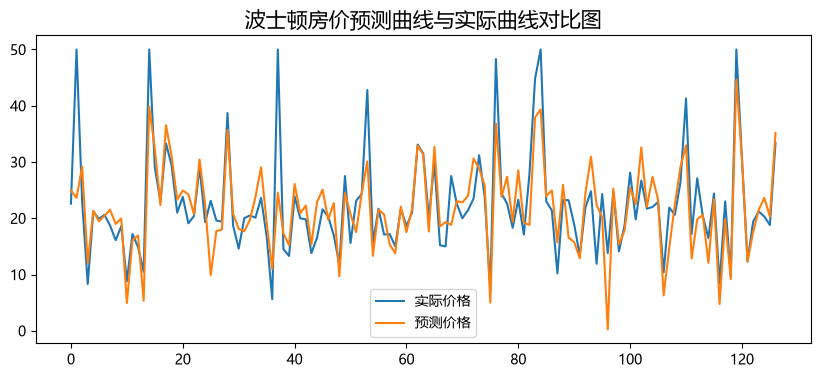

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4)) # 设置画板尺寸(10,4)
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei'] # 设置中文字体
plt.title('波士顿房价预测曲线与实际曲线对比图', fontsize=15)
x = range(len(y_test)) # x轴数据

plt.plot(x, y_test, label='实际价格') # 实际价格曲线
plt.plot(x, y_pred, label='预测价格') # 预测价格曲线
plt.legend() # 显示图例
plt.show()


### 7、使用Ridge（岭回归）建模

In [8]:
from sklearn.datasets import fetch_openml # 引入load_boston函数
from sklearn.model_selection import train_test_split # 引入数据集拆分函数
from sklearn.linear_model import Ridge # 引入Ridge模型

# 加载boston数据集
boston = fetch_openml(name="boston", version=1, as_frame=False, parser='auto')

# 拆分数据集
X_train, X_test, y_train, y_test = train_test_split(boston.data, boston.target,
                                                    test_size=0.25, random_state=0)
# 构建模型并训练
model = Ridge().fit(X_train, y_train)

# 评估模型
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print('train score:{:.2f}'.format(train_score))
print('test  score:{:.2f}'.format(test_score))


train score:0.77
test  score:0.63
